# Advanced Insurance Forecasting — Hồi quy



###Tổng Quan:
1. Đọc & khám sát dữ liệu ban đầu
2. Tiền xử lý dữ liệu (Preprocessing)
  - 2.1 Kiểm tra Duplicate
  - 2.2 Xử lý dữ liệu trùng lặp
  - 2.3 Loại bỏ các biến không cần thiết
  - 2.4 Feature Engineering
  - 2.5 Xử lý Outliers
  - 2.6 Xử lý biến mục tiêu
  - 2.7 Mã hóa biến phân loại (Encoding)
  - 2.8 Tách tập đặc trưng và biến mục tiêu
  - 2.9 Chia dữ liệu
3. Phân tích dữ liệu khám phá (EDA)
  - 3.1 Phân phối biến mục tiêu — trước & sau log transform
  - 3.2 Trip Duration theo giờ trong ngày & ngày trong tuần
  - 3.3 Ma trận tương quan Pearson
4. Huấn luyện mô hình
  - 4.1 Linear Regression (Baseline)
  - 4.2 XGBoost Regressor
  - 4.3 LightGBM Baseline
5.  Đánh giá mô hình


Cài đặt & Import thư viện <a id='buoc0'></a>



In [ ]:
!pip install xgboost lightgbm -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
##  1. Đọc & Khám sát dữ liệu ban đầu



In [ ]:
DATA_PATH = '/content/drive/MyDrive/regression/Training.csv'
df = pd.read_csv(DATA_PATH)
print(f'Số dòng : {df.shape[0]:,}')
print(f'Số cột  : {df.shape[1]}')
display(df.head())

Số dòng : 6,000
Số cột  : 17


,ID,Comp_A_Premium,SafeDrive_Score,Age,Years_Driving,Gender,Vehicle_Type,SC_or_MC?,Points,County_Residence,PIF?,Homowner,Education,Marital_Status,Organ_Donor?,Months_Since_Policy_Inception,Log(SafeDrive_Score)
0,1,877.19,375,45.59,29.59,M,2,SC,5,5,1,1,3,0,0,49.8,5.93
1,2,964.54,458,16.53,0.53,M,4,SC,1,1,1,0,1,0,1,1.1,6.13
2,3,557.24,546,42.68,26.68,F,4,SC,1,13,1,1,2,0,0,88.6,6.30
3,4,611.88,608,67.24,49.96,M,5,MC,2,16,1,1,4,1,1,30.0,6.41
4,6,487.89,552,43.39,27.39,F,5,SC,0,4,1,0,4,1,0,88.1,6.31


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             6000 non-null   int64  
 1   Comp_A_Premium                 6000 non-null   float64
 2   SafeDrive_Score                6000 non-null   int64  
 3   Age                            6000 non-null   float64
 4   Years_Driving                  6000 non-null   float64
 5   Gender                         6000 non-null   object 
 6   Vehicle_Type                   6000 non-null   int64  
 7   SC_or_MC?                      6000 non-null   object 
 8   Points                         6000 non-null   int64  
 9   County_Residence               6000 non-null   int64  
 10  PIF?                           6000 non-null   int64  
 11  Homowner                       6000 non-null   int64  
 12  Education                      6000 non-null   i

In [ ]:
df.describe(include='all')

,ID,Comp_A_Premium,SafeDrive_Score,Age,Years_Driving,Gender,Vehicle_Type,SC_or_MC?,Points,County_Residence,PIF?,Homowner,Education,Marital_Status,Organ_Donor?,Months_Since_Policy_Inception,Log(SafeDrive_Score)
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000,6000.000000,6000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
unique,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,M,NaN,SC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,3046,NaN,3069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3742.978833,725.959250,489.108833,44.435173,27.627662,NaN,3.056000,NaN,2.682333,5.473333,0.837667,0.590833,2.902000,0.499833,0.529167,47.872167,6.149608
std,2168.214557,205.485984,127.526011,16.083265,16.229138,NaN,1.286004,NaN,2.598053,4.815581,0.368787,0.491721,1.053999,0.500042,0.499190,28.683721,0.312501
min,1.000000,261.980000,161.000000,16.000000,0.000000,NaN,1.000000,NaN,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.100000,5.080000
25%,1866.750000,564.495000,425.000000,32.147500,15.130000,NaN,2.000000,NaN,1.000000,2.000000,1.000000,0.000000,2.000000,0.000000,0.000000,22.400000,6.050000
50%,3726.500000,696.940000,525.000000,43.035000,26.060000,NaN,3.000000,NaN,2.000000,4.000000,1.000000,1.000000,3.000000,0.000000,1.000000,47.300000,6.260000
75%,5613.500000,866.105000,578.000000,55.035000,38.342500,NaN,4.000000,NaN,4.000000,7.000000,1.000000,1.000000,4.000000,1.000000,1.000000,72.300000,6.360000


---
## 2.Tiền xử lý dữ liệu (Preprocessing)


### 2.1 Kiểm tra Missing Values


In [ ]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

print("\nTổng số giá trị thiếu:")
print(missing.sum())

Missing Values:
ID                               0
Comp_A_Premium                   0
SafeDrive_Score                  0
Age                              0
Years_Driving                    0
Gender                           0
Vehicle_Type                     0
SC_or_MC?                        0
Points                           0
County_Residence                 0
PIF?                             0
Homowner                         0
Education                        0
Marital_Status                   0
Organ_Donor?                     0
Months_Since_Policy_Inception    0
Log(SafeDrive_Score)             0
dtype: int64

Tổng số giá trị thiếu:
0


### *2.2* Kiểm tra Duplicate


In [ ]:
duplicates = df.duplicated().sum()

print("Số dòng trùng lặp:", duplicates)

Số dòng trùng lặp: 0


### *2.3* Loại bỏ cột ID

In [ ]:
if 'ID' in df.columns:
    print("Số ID duy nhất:", df['ID'].nunique())
    print("Tổng số dòng:", len(df))
df = df.drop(columns=['ID'])
print(df.shape)

Số ID duy nhất: 6000
Tổng số dòng: 6000
(6000, 16)


### *2.4* Feature Engineering

In [ ]:
df['Driving_Start_Age'] = df['Age'] - df['Years_Driving']

df[['Age','Years_Driving','Driving_Start_Age']].head()

,Age,Years_Driving,Driving_Start_Age
0,45.59,29.59,16.00
1,16.53,0.53,16.00
2,42.68,26.68,16.00
3,67.24,49.96,17.28
4,43.39,27.39,16.00


In [ ]:
df['Driving_Experience_Ratio'] = (
    df['Years_Driving'] / df['Age']
)

df[['Driving_Experience_Ratio']].head()

,Driving_Experience_Ratio
0,0.649046
1,0.032063
2,0.625117
3,0.743010
4,0.631251


In [ ]:
df['Risk_Index'] = (
    df['Points'] *
    (100 - df['SafeDrive_Score'])
)

df[['Points','SafeDrive_Score','Risk_Index']].head()

,Points,SafeDrive_Score,Risk_Index
0,5,375,-1375
1,1,458,-358
2,1,546,-446
3,2,608,-1016
4,0,552,0


### *2.5* Xử lý Outlier

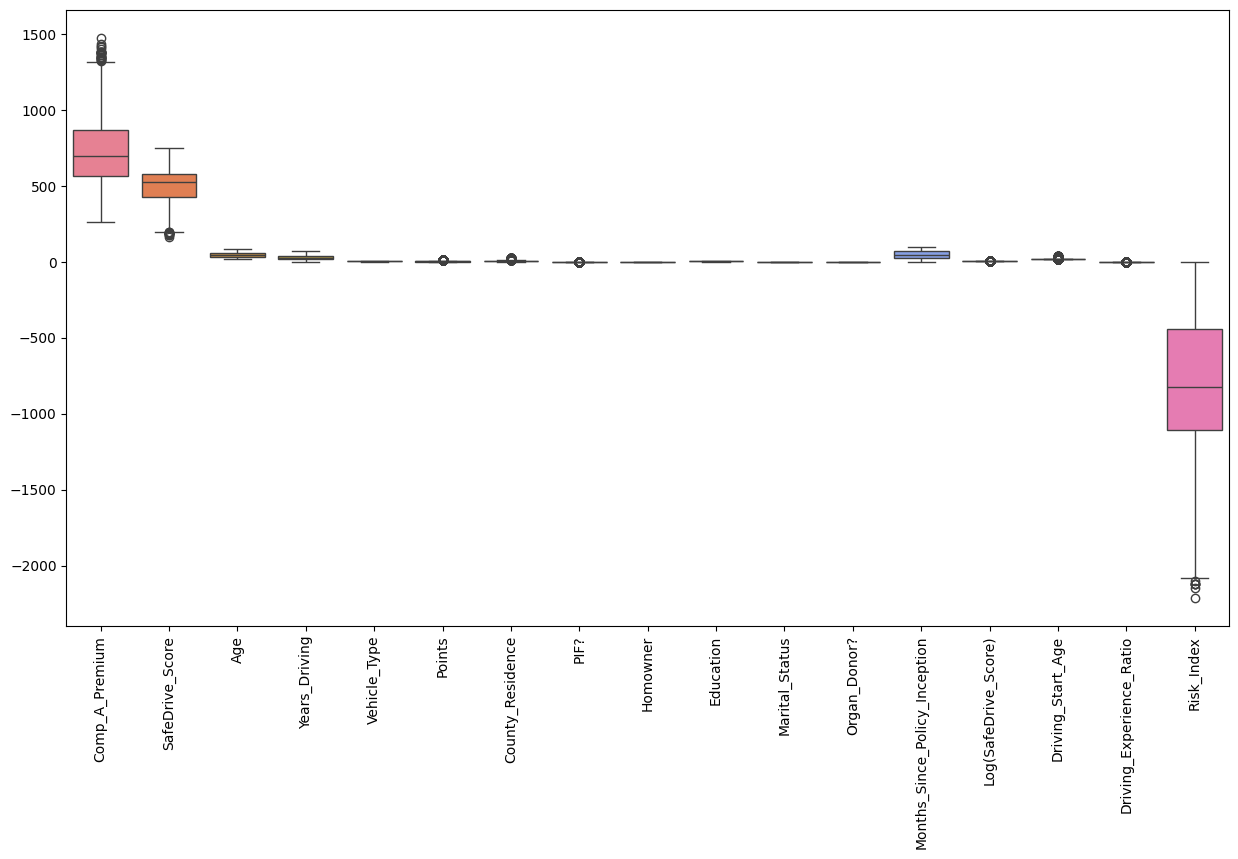

In [ ]:
numeric_cols = df.select_dtypes(
    include=['int64','float64']
).columns

plt.figure(figsize=(15,8))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=90)
plt.show()

### *2.6* Xử lý biến mục tiêu

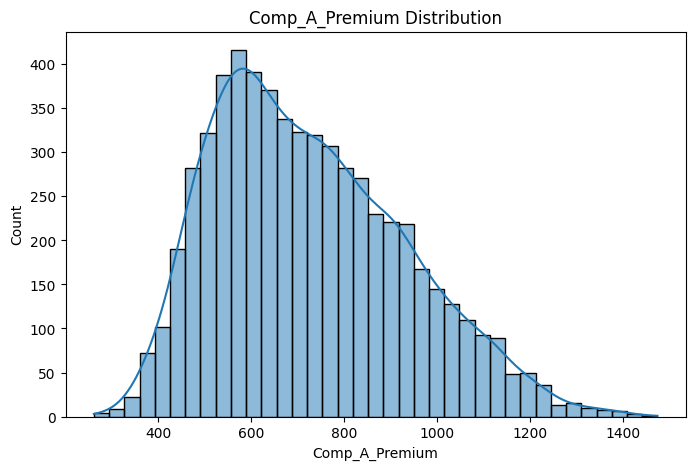

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Comp_A_Premium'],
    kde=True
)

plt.title('Comp_A_Premium Distribution')
plt.show()

In [ ]:
target_skew = skew(df['Comp_A_Premium'])

print("Skewness =", target_skew)

Skewness = 0.5448681862252978


Skewness > 0.5 tức dữ liệu hơi lệch về bên phải.


In [ ]:
df['Comp_A_Premium_Log'] = np.log1p(
    df['Comp_A_Premium']
)

df[['Comp_A_Premium',
    'Comp_A_Premium_Log']].head()

,Comp_A_Premium,Comp_A_Premium_Log
0,877.19,6.777863
1,964.54,6.872688
2,557.24,6.324789
3,611.88,6.418169
4,487.89,6.192138


In [ ]:
print(f'  Skewness trước log : {skew(df['Comp_A_Premium']):.2f}')
print(f'  Skewness sau log   : {skew(df['Comp_A_Premium_Log']):.2f}')

  Skewness trước log : 0.54
  Skewness sau log   : -0.04


### *2.7* Mã hóa biến phân loại (Encoding)

In [ ]:
categorical_cols = df.select_dtypes(
    include='object'
).columns

print(categorical_cols)

Index(['Gender', 'SC_or_MC?'], dtype='object')


In [ ]:
binary_cols = [
    'Gender',
    'SC_or_MC?',
    'PIF?',
    'Homeowner',
    'Organ_Donor?'
]

le = LabelEncoder()

for col in binary_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

df.head()

,Comp_A_Premium,SafeDrive_Score,Age,Years_Driving,Gender,Vehicle_Type,SC_or_MC?,Points,County_Residence,PIF?,Homowner,Education,Marital_Status,Organ_Donor?,Months_Since_Policy_Inception,Log(SafeDrive_Score),Driving_Start_Age,Driving_Experience_Ratio,Risk_Index,Comp_A_Premium_Log
0,877.19,375,45.59,29.59,1,2,1,5,5,1,1,3,0,0,49.8,5.93,16.00,0.649046,-1375,6.777863
1,964.54,458,16.53,0.53,1,4,1,1,1,1,0,1,0,1,1.1,6.13,16.00,0.032063,-358,6.872688
2,557.24,546,42.68,26.68,0,4,1,1,13,1,1,2,0,0,88.6,6.30,16.00,0.625117,-446,6.324789
3,611.88,608,67.24,49.96,1,5,0,2,16,1,1,4,1,1,30.0,6.41,17.28,0.743010,-1016,6.418169
4,487.89,552,43.39,27.39,0,5,1,0,4,1,0,4,1,0,88.1,6.31,16.00,0.631251,0,6.192138


In [ ]:
df = pd.get_dummies(
    df,
    columns=['Vehicle_Type'],
    drop_first=True
)
df.head()

,Comp_A_Premium,SafeDrive_Score,Age,Years_Driving,Gender,SC_or_MC?,Points,County_Residence,PIF?,Homowner,...,Months_Since_Policy_Inception,Log(SafeDrive_Score),Driving_Start_Age,Driving_Experience_Ratio,Risk_Index,Comp_A_Premium_Log,Vehicle_Type_2,Vehicle_Type_3,Vehicle_Type_4,Vehicle_Type_5
0,877.19,375,45.59,29.59,1,1,5,5,1,1,...,49.8,5.93,16.00,0.649046,-1375,6.777863,True,False,False,False
1,964.54,458,16.53,0.53,1,1,1,1,1,0,...,1.1,6.13,16.00,0.032063,-358,6.872688,False,False,True,False
2,557.24,546,42.68,26.68,0,1,1,13,1,1,...,88.6,6.30,16.00,0.625117,-446,6.324789,False,False,True,False
3,611.88,608,67.24,49.96,1,0,2,16,1,1,...,30.0,6.41,17.28,0.743010,-1016,6.418169,False,False,False,True
4,487.89,552,43.39,27.39,0,1,0,4,1,0,...,88.1,6.31,16.00,0.631251,0,6.192138,False,False,False,True


### *2.8* Tách tập đặc trưng và biến mục tiêu

In [ ]:
X = df.drop(
    columns=[
        'Comp_A_Premium',
        'Comp_A_Premium_Log'
    ]
)
y = df['Comp_A_Premium_Log']

### *2.9* Chia dữ liệu

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4800, 21)
(1200, 21)


### *2.10* Chuẩn hóa dữ liệu cho Linear Regression

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

---
## 3.Phân tích khám phá dữ liệu (EDA)


Biến gốc Comp_A_Premium có phân phối lệch phải. Phần đuôi của đồ thị kéo dài về phía bên phải.

Chỉ số độ lệch Skewness bằng 0.54. Giá trị này lớn hơn 0, xác nhận phân phối lệch phải ở mức độ vừa phải.

Sau khi áp dụng log1p(Comp_A_Premium), phân phối đã thay đổi rõ rệt. Đồ thị trở nên cân đối, bo tròn đều hai bên và có hình dáng rất gần với phân phối chuẩn.

Chỉ số độ lệch Skewness giảm mạnh xuống còn -0.04. Giá trị này cực kỳ gần bằng 0, chứng tỏ phân phối đã đạt được độ đối xứng gần như hoàn hảo.

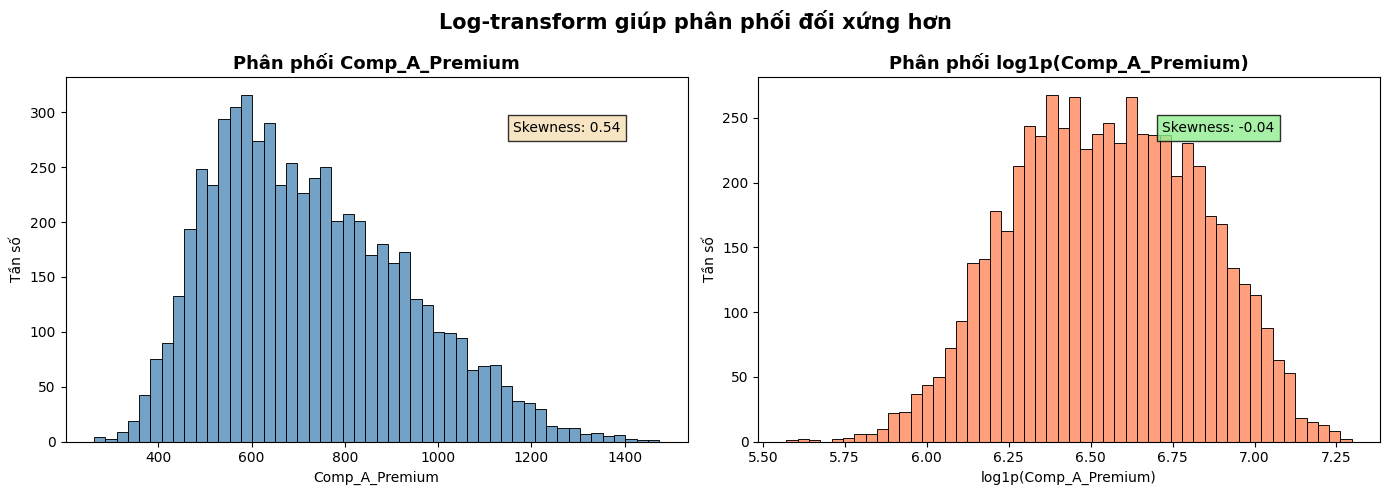

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot( df['Comp_A_Premium'], bins=50, color='steelblue', ax=ax[0])
ax[0].set_title("Phân phối Comp_A_Premium", fontsize=13, weight='bold')
ax[0].set_xlabel("Comp_A_Premium")
ax[0].set_ylabel("Tần số")
ax[0].text( 0.72, 0.85, f"Skewness: {skew(df['Comp_A_Premium']):.2f}",
      transform=ax[0].transAxes, bbox=dict(facecolor='wheat', alpha=0.8))
sns.histplot( df['Comp_A_Premium_Log'], bins=50, color='coral', ax=ax[1])
ax[1].set_title("Phân phối log1p(Comp_A_Premium)", fontsize=13, weight='bold')
ax[1].set_xlabel("log1p(Comp_A_Premium)")
ax[1].set_ylabel("Tần số")

ax[1].text( 0.65, 0.85, f"Skewness: {skew(df['Comp_A_Premium_Log']):.2f}",
      transform=ax[1].transAxes, bbox=dict(facecolor='lightgreen', alpha=0.8))
fig.suptitle("Log-transform giúp phân phối đối xứng hơn", fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

### *3.1* Heatmap tương quan

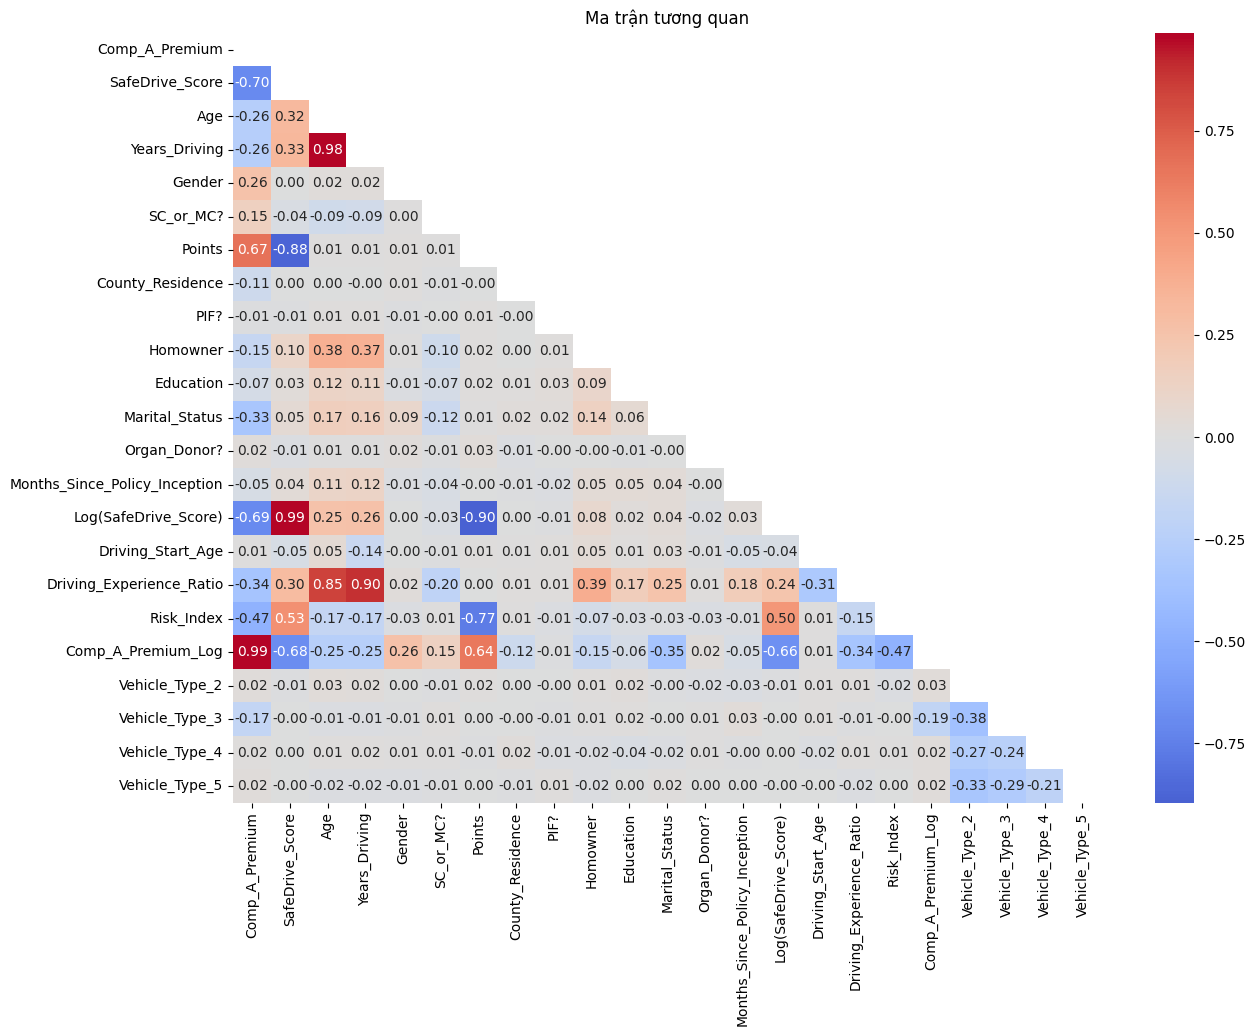

In [ ]:
corr_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Ma trận tương quan')
plt.show()

### *3.2* Tương quan với Premium

In [ ]:
corr = df.corr()['Comp_A_Premium']

corr.sort_values(
    ascending=False
)

,Comp_A_Premium
Comp_A_Premium,1.000000
Comp_A_Premium_Log,0.986432
Points,0.671159
Gender,0.256696
SC_or_MC?,0.152467
Organ_Donor?,0.019964
Vehicle_Type_5,0.018920
Vehicle_Type_2,0.017938
Vehicle_Type_4,0.016433
Driving_Start_Age,0.005842


---
## 4. Xây dựng mô hình Regression

### *4.1* Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
mae = mean_absolute_error(
    y_test,
    pred_lr
)
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lr
    )
)
r2 = r2_score(
    y_test,
    pred_lr
)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.1059733924116483
RMSE: 0.12980391875091754
R2  : 0.7745948144940195


In [ ]:
df.columns

Index(['Comp_A_Premium', 'SafeDrive_Score', 'Age', 'Years_Driving', 'Gender',
       'SC_or_MC?', 'Points', 'County_Residence', 'PIF?', 'Homowner',
       'Education', 'Marital_Status', 'Organ_Donor?',
       'Months_Since_Policy_Inception', 'Log(SafeDrive_Score)',
       'Driving_Start_Age', 'Driving_Experience_Ratio', 'Risk_Index',
       'Comp_A_Premium_Log', 'Vehicle_Type_2', 'Vehicle_Type_3',
       'Vehicle_Type_4', 'Vehicle_Type_5'],
      dtype='object')

### *4.2* XGBoost

In [ ]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

mae = mean_absolute_error(y_test, pred_xgb)

rmse = np.sqrt(
    mean_squared_error(y_test, pred_xgb)
)

r2 = r2_score(y_test, pred_xgb)

print("XGBoost")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

XGBoost
MAE : 0.057345485924058505
RMSE: 0.07378467825047906
R2  : 0.9271682625142639


### *4.3* LightGBMInception

In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    random_state=42,
    learning_rate=0.05,
    n_estimators=500,
    min_child_samples=30,
    verbose=-1
)

lgbm.fit(X_train, y_train)

pred_lgbm = lgbm.predict(X_test)
mae = mean_absolute_error(y_test, pred_lgbm)

rmse = np.sqrt(
    mean_squared_error(y_test, pred_lgbm)
)

r2 = r2_score(y_test, pred_lgbm)

print("LightGBM")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

LightGBM
MAE : 0.05877728521163386
RMSE: 0.0756563147607687
R2  : 0.9234264713233633


In [ ]:
train_preds = lgbm.predict(X_train)
r2_train = r2_score(y_train, train_preds)
print("R2 Train:", r2_train)
print("R2 Test :", r2)

R2 Train: 0.9770666749799971
R2 Test : 0.9234264713233633


In [ ]:
lgbm = LGBMRegressor(
    random_state=42,
    max_depth=5,
    learning_rate=0.03,
    n_estimators=600,
    min_child_samples=30,
    verbose=-1
)
lgbm.fit(X_train, y_train)

pred_lgbm = lgbm.predict(X_test)
mae = mean_absolute_error(y_test, pred_lgbm)

rmse = np.sqrt(
    mean_squared_error(y_test, pred_lgbm)
)

r2 = r2_score(y_test, pred_lgbm)

print("LightGBM")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

LightGBM
MAE : 0.057010308619255406
RMSE: 0.07321182865045844
R2  : 0.928294774777741


---
## 5. Đánh giá và So sánh mô hình

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression','XGBoost','LightGBM'],
    'MAE': [
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_xgb),
        mean_absolute_error(y_test,pred_lgbm)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test,pred_lr)),
        np.sqrt(mean_squared_error(y_test,pred_xgb)),
        np.sqrt(mean_squared_error(y_test,pred_lgbm))
    ],
    'R2': [
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_xgb),
        r2_score(y_test,pred_lgbm)
    ]
})

results.sort_values('R2', ascending=False)

,Model,MAE,RMSE,R2
2,LightGBM,0.057010,0.073212,0.928295
1,XGBoost,0.057345,0.073785,0.927168
0,Linear Regression,0.105973,0.129804,0.774595


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
12,Months_Since_Policy_Inception,1606
0,SafeDrive_Score,1445
1,Age,1327
16,Risk_Index,1228
6,County_Residence,1168
15,Driving_Experience_Ratio,793
2,Years_Driving,754
9,Education,747
18,Vehicle_Type_3,697
3,Gender,663


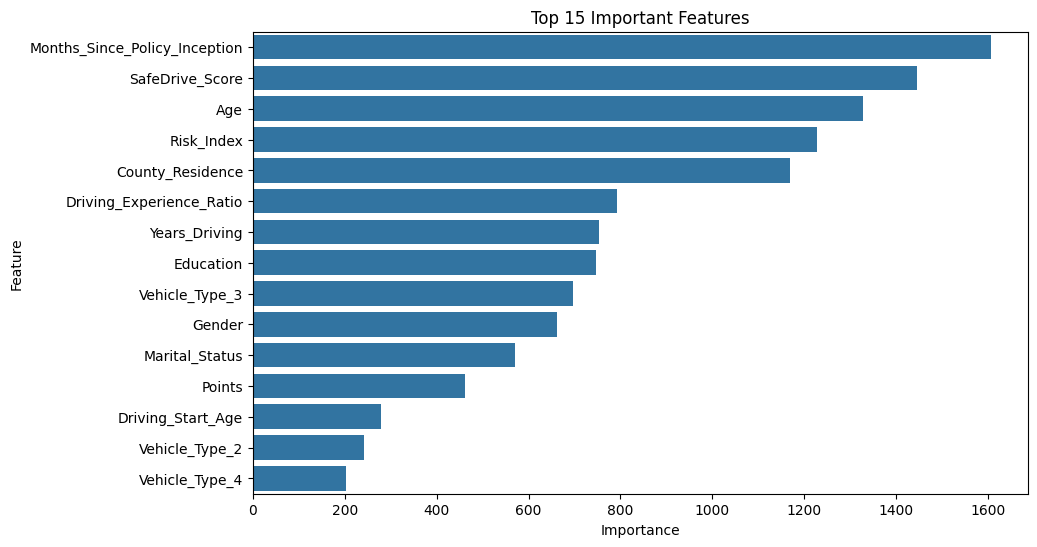

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Important Features')
plt.show()